## STANBIC STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

stanbic=pd.read_csv('../stock_data/stanbic.csv') ## so it can be small letter. This is cool.
stanbic=stanbic.drop(columns=['high_price','low_price'])
stanbic.rename(columns={'trade_date':'date'},inplace=True)
stanbic['date']=pd.to_datetime(stanbic['date'])
stanbic['month']=stanbic['date'].dt.month
stanbic['quarter']=stanbic['date'].dt.quarter
stanbic['year']=stanbic['date'].dt.year

stanbic

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42828,STANBIC,2017-01-03,15.69,15.69,339614,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43388,STANBIC,2017-01-04,15.63,15.63,444035,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43498,STANBIC,2017-01-05,15.00,15.00,2203637,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43608,STANBIC,2017-01-06,15.00,15.00,380047,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43698,STANBIC,2017-01-09,15.00,15.00,1398252,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298132,STANBIC,2026-07-13,157.00,157.00,18375845,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298570,STANBIC,2026-07-14,163.00,163.00,7347207,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299008,STANBIC,2026-07-15,166.90,166.90,22776167,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299446,STANBIC,2026-07-16,166.90,166.90,212905,2026-07-16T15:10:03.113936+00:00,7,3,2026


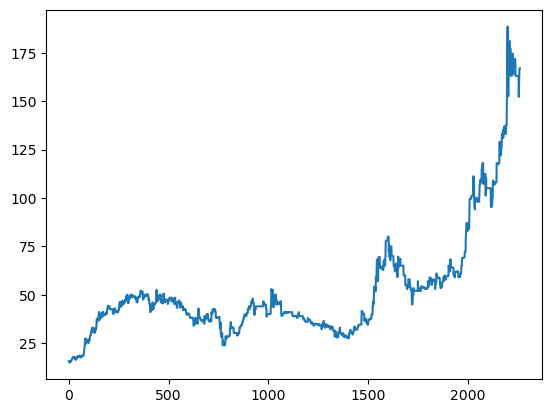

In [2]:
import matplotlib.pyplot as plt

plt.plot(stanbic['close_price'])
plt.show()

In [3]:
stanbic_end_month_df = (
    stanbic
    .sort_values("date")
    .groupby(stanbic["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

stanbic_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45398,STANBIC,2017-01-31,17.30,17.30,904141,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47220,STANBIC,2017-02-28,17.98,17.98,474054,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49336,STANBIC,2017-03-31,17.78,17.78,2029894,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51163,STANBIC,2017-04-28,26.25,26.25,2815624,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53086,STANBIC,2017-05-31,26.00,26.00,2946848,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35369,STANBIC,2026-03-31,133.10,133.10,1603016,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281195,STANBIC,2026-04-30,165.00,165.00,1826420,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284261,STANBIC,2026-05-29,169.35,169.35,1279885,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294189,STANBIC,2026-06-30,163.00,163.00,602288,2026-06-30T15:10:03.08168+00:00,6,2,2026


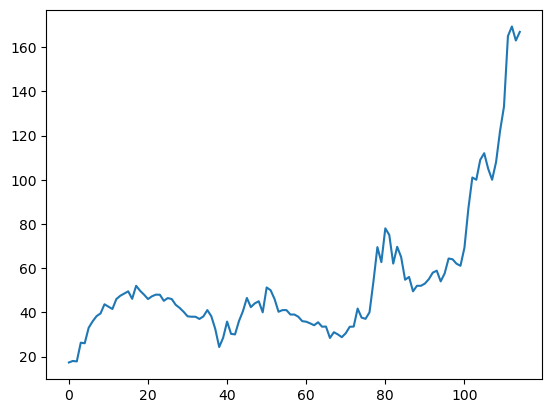

In [4]:
plt.plot(stanbic_end_month_df['close_price'])
plt.show()

In [5]:
stanbic_end_month_df['returns']=stanbic_end_month_df['close_price'].pct_change()*100
stanbic_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45398,STANBIC,2017-01-31,17.30,17.30,904141,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47220,STANBIC,2017-02-28,17.98,17.98,474054,2026-04-08T02:44:45.006295+00:00,2,1,2017,3.930636
2,49336,STANBIC,2017-03-31,17.78,17.78,2029894,2026-04-08T02:45:42.281198+00:00,3,1,2017,-1.112347
3,51163,STANBIC,2017-04-28,26.25,26.25,2815624,2026-04-08T02:51:55.619599+00:00,4,2,2017,47.637795
4,53086,STANBIC,2017-05-31,26.00,26.00,2946848,2026-04-08T02:52:57.421655+00:00,5,2,2017,-0.952381
...,...,...,...,...,...,...,...,...,...,...,...
110,35369,STANBIC,2026-03-31,133.10,133.10,1603016,2026-03-31T15:00:02.085058+00:00,3,1,2026,9.098361
111,281195,STANBIC,2026-04-30,165.00,165.00,1826420,2026-04-30T15:00:02.170664+00:00,4,2,2026,23.966942
112,284261,STANBIC,2026-05-29,169.35,169.35,1279885,2026-05-29T15:00:02.455558+00:00,5,2,2026,2.636364
113,294189,STANBIC,2026-06-30,163.00,163.00,602288,2026-06-30T15:10:03.08168+00:00,6,2,2026,-3.749631


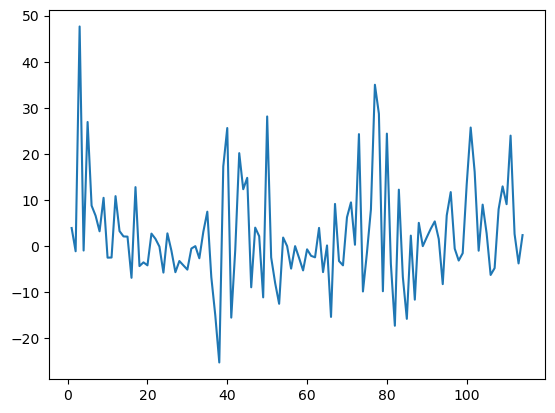

In [6]:
plt.plot(stanbic_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(stanbic_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-10.05419151347179, 1.3869554734059892e-17, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 763.9113175034142)
stationary


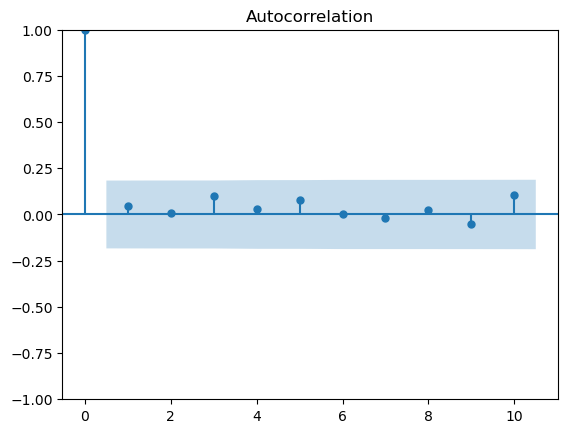

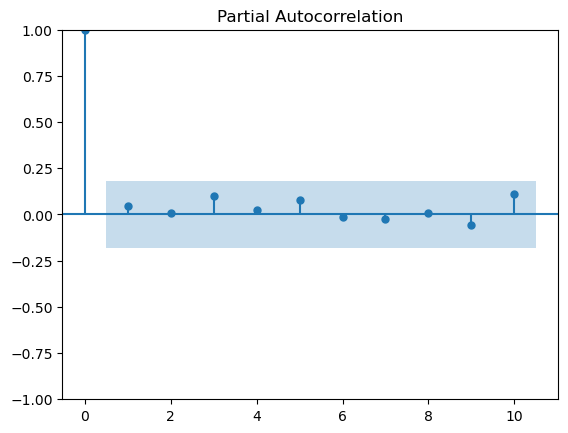

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(stanbic_end_month_df['returns'].dropna(), lags=10)
plot_pacf(stanbic_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=stanbic_end_month_df['close_price'][:-10]
test=stanbic_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -24.311124795326684]
[0, 0, 0, 0, 0, 1, -13.442545921325465]
[0, 0, 0, 0, 0, 2, -9.831975153100393]
[0, 0, 0, 0, 1, 0, -5.524478691527427]
[0, 0, 0, 0, 1, 1, -6.8961649577937285]
[0, 0, 0, 0, 1, 2, -4.632440311806615]
[0, 0, 0, 0, 2, 0, -4.010946905381832]
[0, 0, 0, 0, 2, 1, -4.666952889146775]
[0, 0, 0, 0, 2, 2, -2.606400960549382]
[0, 0, 0, 1, 0, 0, -6.218168753455009]
[0, 0, 0, 1, 0, 1, -7.394705256304482]
[0, 0, 0, 1, 0, 2, -5.193286811456723]
[0, 0, 0, 1, 1, 0, -6.695890579172513]
[0, 0, 0, 1, 1, 1, -6.561019466028421]
[0, 0, 0, 1, 1, 2, -4.855757921951518]
[0, 0, 0, 1, 2, 0, -3.369026338194958]
[0, 0, 0, 1, 2, 1, -4.436682747000526]
[0, 0, 0, 1, 2, 2, -2.7792184479347726]
[0, 0, 0, 2, 0, 0, -7.074154543833963]
[0, 0, 0, 2, 0, 1, -6.966208432329916]
[0, 0, 0, 2, 0, 2, -5.336295807040569]
[0, 0, 0, 2, 1, 0, -6.403825797605145]
[0, 0, 0, 2, 1, 1, -6.112354511496113]
[0, 0, 0, 2, 1, 2, -5.545621805920028]
[0, 0, 0, 2, 2, 0, -3.7990571628051972]
[0, 0, 0, 2, 2, 1, -

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-24.311125
27,0,0,1,0,0,0,-22.943304
54,0,0,2,0,0,0,-21.805652
168,0,2,0,0,2,0,-21.746995
74,0,0,2,2,0,2,-17.836058
...,...,...,...,...,...,...,...
424,1,2,0,2,0,1,0.700625
415,1,2,0,1,0,1,0.700716
423,1,2,0,2,0,0,0.701180
407,1,2,0,0,0,2,0.701281


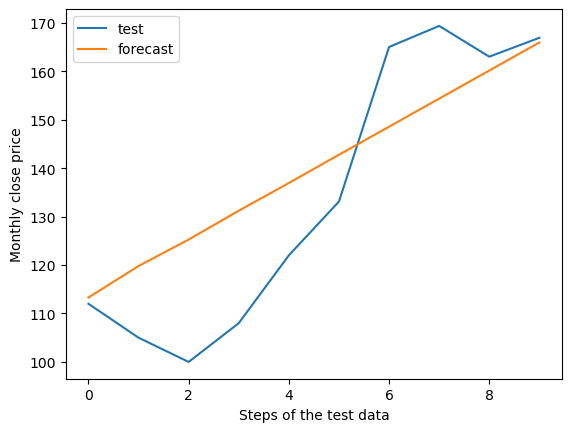

r2_score:  0.7015876295171741
rmse:  14.894236187713341
description:  count    115.000000
mean      53.594957
std       30.500424
min       17.300000
25%       37.025000
50%       45.000000
75%       56.800000
max      169.350000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=stanbic_end_month_df['close_price'][:-10]
y_test=stanbic_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', stanbic_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=stanbic_end_month_df['returns'].dropna()[:-10]
test=stanbic_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.289754074753517]
[0, 0, 0, 0, 0, 1, -0.305787654174559]
[0, 0, 0, 0, 0, 2, -0.2583672300283053]
[0, 0, 0, 0, 1, 0, -2.014618776344073]
[0, 0, 0, 0, 1, 1, -0.23066417390797334]
[0, 0, 0, 0, 1, 2, -0.36585231987192723]
[0, 0, 0, 0, 2, 0, -5.972666555775579]
[0, 0, 0, 0, 2, 1, -2.633010781811349]
[0, 0, 0, 0, 2, 2, -3.0127231918820305]
[0, 0, 0, 1, 0, 0, -0.3131795029188498]
[0, 0, 0, 1, 0, 1, -0.281821298728935]
[0, 0, 0, 1, 0, 2, -0.24119940041841947]
[0, 0, 0, 1, 1, 0, -1.7671791470256495]
[0, 0, 0, 1, 1, 1, -0.3433937346875966]
[0, 0, 0, 1, 1, 2, -0.2470459251562649]
[0, 0, 0, 1, 2, 0, -2.5557529090934703]
[0, 0, 0, 1, 2, 1, -2.675034610623693]
[0, 0, 0, 1, 2, 2, -2.926413788892589]
[0, 0, 0, 2, 0, 0, -0.2563003965925128]
[0, 0, 0, 2, 0, 1, -0.2427236067402776]
[0, 0, 0, 2, 0, 2, -0.24276708020395832]
[0, 0, 0, 2, 1, 0, -1.889805406859605]
[0, 0, 0, 2, 1, 1, -0.447753588379612]
[0, 0, 0, 2, 1, 2, -0.14349581381890664]
[0, 0, 0, 2, 2, 0, -4.58396721987619]
[0, 0, 

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-1090.965801
173,0,2,0,1,0,2,-200.868156
164,0,2,0,0,0,2,-196.614535
182,0,2,0,2,0,2,-189.353339
180,0,2,0,2,0,0,-188.021935
...,...,...,...,...,...,...,...
397,1,1,2,2,0,1,0.132322
389,1,1,2,1,0,2,0.133581
353,1,1,1,0,0,2,0.144976
110,0,1,1,0,0,2,0.147606


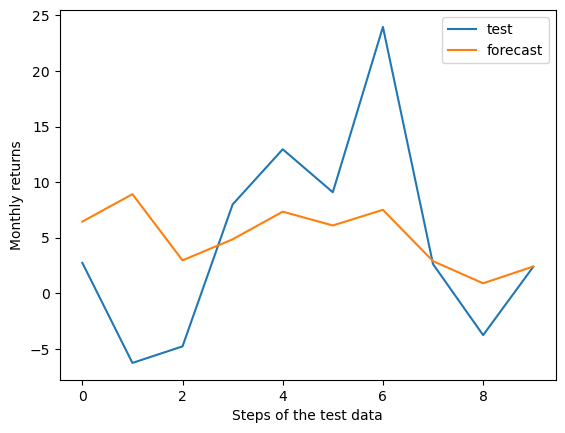

r2_score:  0.15369986978053085
rmse:  8.040606855978028
description:  count    114.000000
mean       2.604157
std       11.409025
min      -25.230769
25%       -4.086538
50%        0.074627
75%        7.839288
max       47.637795
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=stanbic_end_month_df['returns'].dropna()[:-10]
y_test=stanbic_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,1,2), 
seasonal_order=(0,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', stanbic_end_month_df.returns.dropna().describe())

Not good enough though
